In [118]:
%pip install kagglehub pandas numpy plotly seaborn kagglehub scipy

Note: you may need to restart the kernel to use updated packages.


In [119]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import kagglehub
import json 
from scipy.stats import shapiro, levene, ttest_ind

In [120]:
path = kagglehub.dataset_download("tmdb/tmdb-movie-metadata")

print("Path to dataset files:", path)



path2 = kagglehub.dataset_download("grouplens/movielens-20m-dataset")

print("Path to dataset files:", path2)

Path to dataset files: /home/neuromancer/.cache/kagglehub/datasets/tmdb/tmdb-movie-metadata/versions/2
Path to dataset files: /home/neuromancer/.cache/kagglehub/datasets/grouplens/movielens-20m-dataset/versions/1


- # Carregando Datasets

In [121]:
df_tmdb = pd.read_csv("tmdb/tmdb_5000_movies.csv")
df_rating = pd.read_csv("movie_lens/rating.csv" )
df_link = pd.read_csv("movie_lens/link.csv")

In [122]:
df_link['id'] = df_link['tmdbId'].astype(str) + "_" + df_link['movieId'].astype(str)

#df_merged.drop(columns=['Id'], inplace=True)

In [123]:
df_tmdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [124]:
df_rating.head()

,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40


In [125]:
df_link.head()

,movieId,imdbId,tmdbId,id
0,1,114709,862.0,862.0_1
1,2,113497,8844.0,8844.0_2
2,3,113228,15602.0,15602.0_3
3,4,114885,31357.0,31357.0_4
4,5,113041,11862.0,11862.0_5


- # Megeando dataset link.csv com o dataset rating.csv (movie lens)

In [126]:
df_link_rating = pd.merge(df_link, df_rating, on='movieId', how='inner')


- # Removendo colunas inúteis

In [127]:
df_link_rating.drop(columns=['imdbId','userId', 'timestamp'], inplace=True)

In [128]:
df_link_rating.head()


,movieId,tmdbId,id,rating
0,1,862.0,862.0_1,4.0
1,1,862.0,862.0_1,5.0
2,1,862.0,862.0_1,4.0
3,1,862.0,862.0_1,4.0
4,1,862.0,862.0_1,4.5


# Encontrando o rating médio, para não termos múltiplas linhas no dataset megeado a frete

In [129]:
x = df_link_rating.groupby(['movieId', 'tmdbId'])['rating'].mean().reset_index(name="rating_mean").sort_values(by='movieId', ascending=True)

- Resultado

In [130]:
x.head(2)

,movieId,tmdbId,rating_mean
0,1,862.0,3.921240
1,2,8844.0,3.211977


Text(0, 0.5, 'Rating Medio')

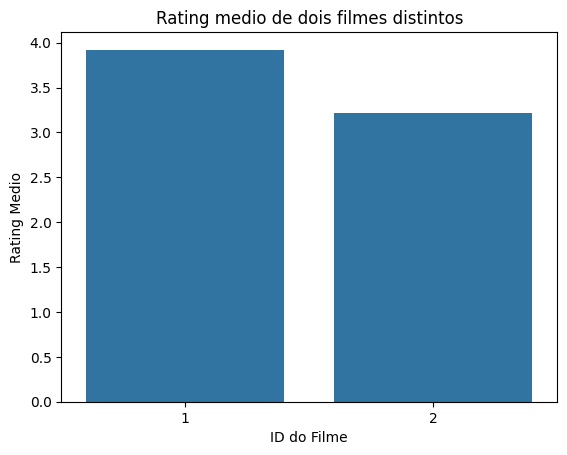

In [131]:
sns.barplot(x='movieId', y='rating_mean', data=x.head(2))
plt.title("Rating medio de dois filmes distintos")
plt.xlabel("ID do Filme")
plt.ylabel("Rating Medio")

##  Agora, nós iremos mergear esse resultado parcial com o datasete TMDB 💀

In [132]:

df_link_rating.dropna(subset=['tmdbId'], inplace=True)
# Tranformando id do df parcial para int, para pagar com o df tmdb
df_link_rating['tmdbId'] = df_link_rating['tmdbId'].astype(int)


df_linked_to_tmdb = pd.merge(x, df_tmdb, left_on='tmdbId', right_on='id', how='inner')


- Temos agora um dataset movie_lens mergeado com o dataset tmdb

In [133]:
df_linked_to_tmdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4222 entries, 0 to 4221
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   movieId               4222 non-null   int64  
 1   tmdbId                4222 non-null   float64
 2   rating_mean           4222 non-null   float64
 3   budget                4222 non-null   int64  
 4   genres                4222 non-null   object 
 5   homepage              1475 non-null   object 
 6   id                    4222 non-null   int64  
 7   keywords              4222 non-null   object 
 8   original_language     4222 non-null   object 
 9   original_title        4222 non-null   object 
 10  overview              4222 non-null   object 
 11  popularity            4222 non-null   float64
 12  production_companies  4222 non-null   object 
 13  production_countries  4222 non-null   object 
 14  release_date          4222 non-null   object 
 15  revenue              

- Obviamente, como tinhamos somente 5000 entradas no dataset original, algumas delas nulas, nós temos pouco mais de 4000 entradas agora 😂

In [134]:
df = df_linked_to_tmdb

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4222 entries, 0 to 4221
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   movieId               4222 non-null   int64  
 1   tmdbId                4222 non-null   float64
 2   rating_mean           4222 non-null   float64
 3   budget                4222 non-null   int64  
 4   genres                4222 non-null   object 
 5   homepage              1475 non-null   object 
 6   id                    4222 non-null   int64  
 7   keywords              4222 non-null   object 
 8   original_language     4222 non-null   object 
 9   original_title        4222 non-null   object 
 10  overview              4222 non-null   object 
 11  popularity            4222 non-null   float64
 12  production_companies  4222 non-null   object 
 13  production_countries  4222 non-null   object 
 14  release_date          4222 non-null   object 
 15  revenue              

Text(0, 0.5, 'Quantidade de Filmes')

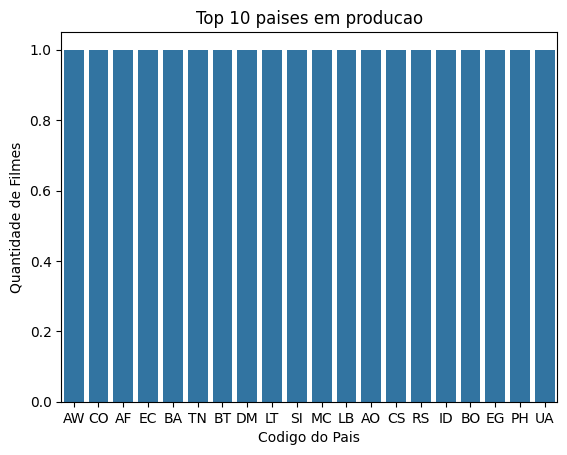

In [ ]:
def extract_country_codes(json_str):
    try:
        if not json_str or json_str.strip() == '[]':
            return []
        
        production_countries_list = json.loads(json_str)
        
        country_codes = [item['iso_3166_1'] for item in production_countries_list if 'iso_3166_1' in item]
        return country_codes
    except json.JSONDecodeError:
        return []

df['country_codes'] = df['production_countries'].apply(extract_country_codes)

country_code_counts = df.explode('country_codes')['country_codes'].value_counts()

top_10_countries = country_code_counts.tail(20)
sns.barplot(x=top_10_countries.index, y=top_10_countries.values)
plt.title("Top 10 paises em producao")
plt.xlabel("Codigo do Pais")
plt.ylabel("Quantidade de Filmes")

In [194]:


y_taglines = y[y['production_countries'] == 'US']['tagline'].dropna().reset_index(drop=True)


# br_films = y[y['production_countries'] == 'BR'].dropna()
# br_films

y_taglines[1000]

'A New Breed Of Secret Agent.'

In [136]:
y = df.copy()
y['production_countries'] = y['production_countries'].replace(np.nan, '[]')
y['production_countries'] = y['production_countries'].astype(str)
y['production_countries'] = y['production_countries'].apply(lambda x: eval(x)[0]['iso_3166_1'] if x != '[]' else None)

In [137]:
y.head(1)

,movieId,tmdbId,rating_mean,budget,genres,homepage,id,keywords,original_language,original_title,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,country_codes
0,1,862.0,3.92124,30000000,"[{""id"": 16, ""name"": ""Animation""}, {""id"": 35, ""...",http://toystory.disney.com/toy-story,862,"[{""id"": 931, ""name"": ""jealousy""}, {""id"": 4290,...",en,Toy Story,...,1995-10-30,373554033,81.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,NaN,Toy Story,7.7,5269,[US]


- Agora agruparemos por grupo

# Budget total dos países

<Axes: xlabel='production_countries'>

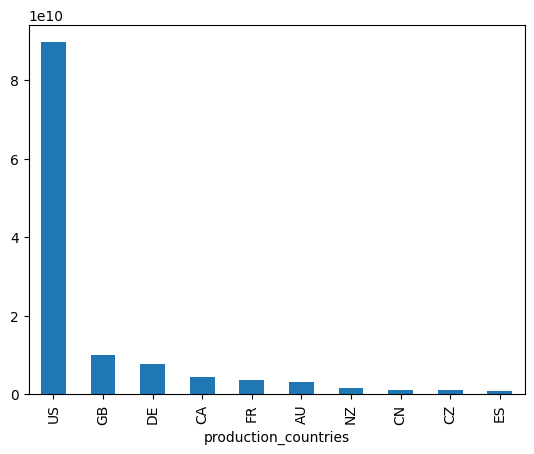

In [138]:
y.groupby('production_countries')['budget'].sum().sort_values(ascending=False).head(10).plot(kind='bar')

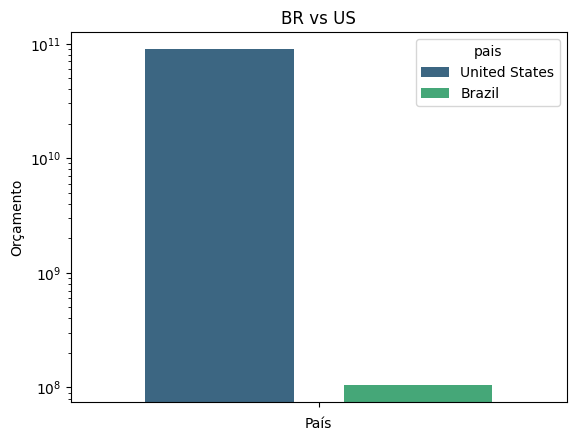

In [139]:

total_budget_us = y[y['production_countries'] == 'US']['budget'].sum()
total_budget_br = y[y['production_countries'] == 'BR']['budget'].sum()

budget_df = pd.DataFrame({
    'pais': ['United States', 'Brazil'],
    'budget': [total_budget_us, total_budget_br]
})

sns.barplot(data=budget_df, hue='pais', y='budget', palette='viridis', gap=0.25)
plt.xlabel('País')
plt.ylabel('Orçamento')
plt.title('BR vs US')
plt.yscale('log')
plt.show()

# Interpretação
- Filmes brasileiros gastam obviamente ordens de gradeza menos dinheiros para suas produções.

Shapiro-Wilk Test (US): ShapiroResult(statistic=np.float64(0.7552130840028743), pvalue=np.float64(1.9043259596154122e-53))
Shapiro-Wilk Test (BR): ShapiroResult(statistic=np.float64(0.7558112274861877), pvalue=np.float64(0.0063310891792624354))
Levene's Test: LeveneResult(statistic=np.float64(2.090458985837172), pvalue=np.float64(0.1483347429833334))
T-test: TtestResult(statistic=np.float64(1.5131583621604152), pvalue=np.float64(0.13035360128173934), df=np.float64(2768.0))


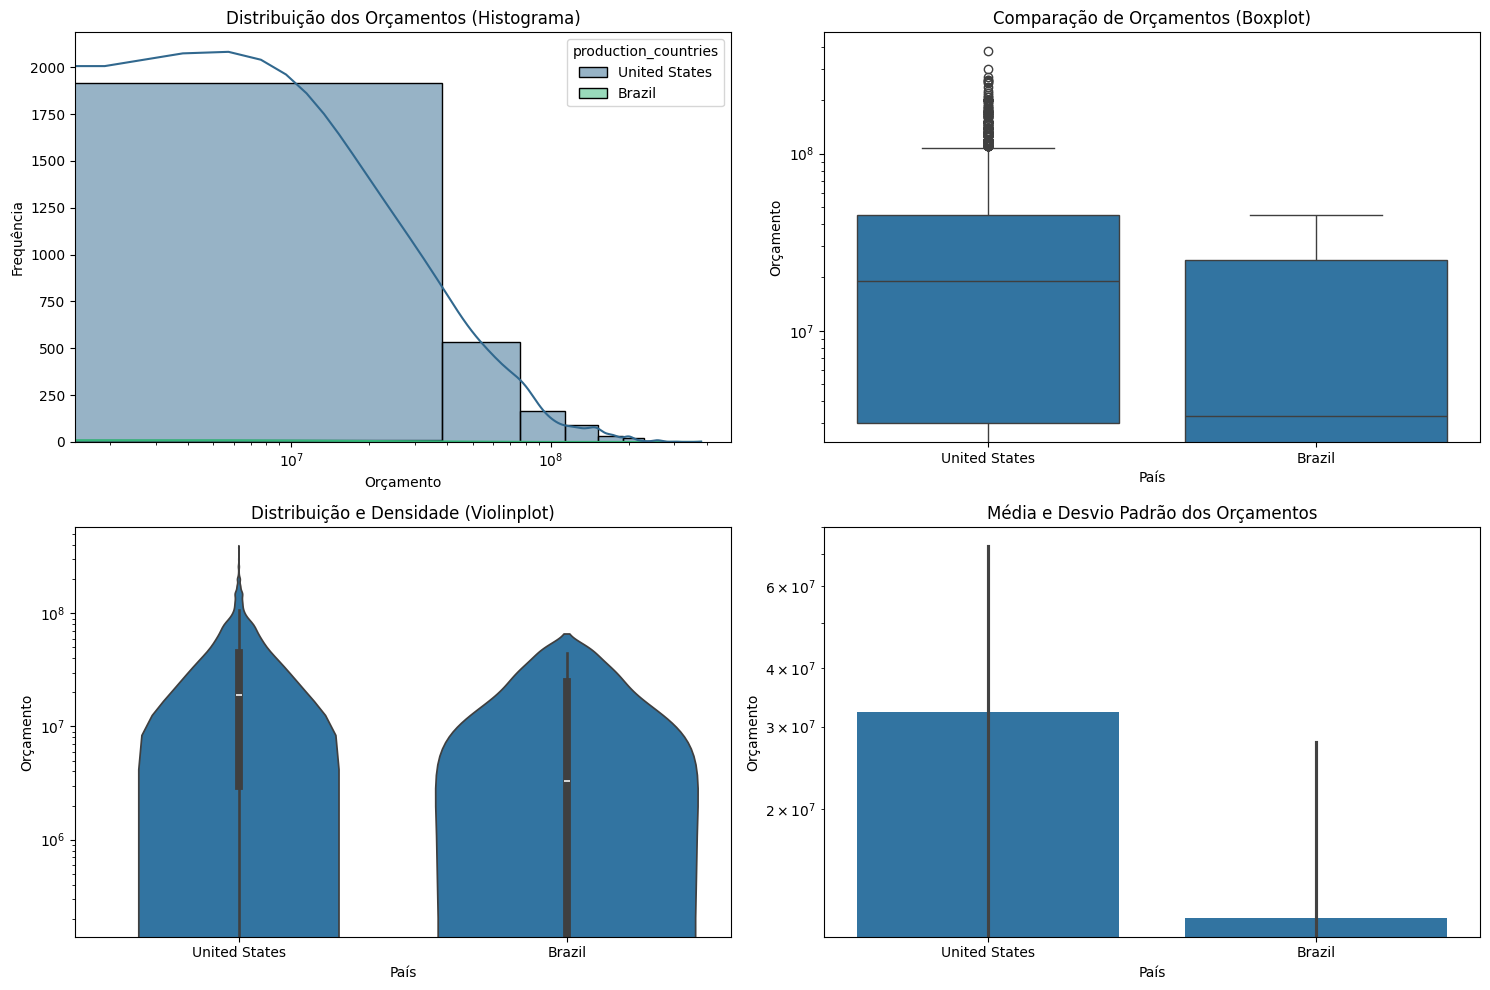

In [164]:
high_rating_films = y[y['vote_average'] >= 4.0]

us_budgets = (high_rating_films[high_rating_films['production_countries'] == 'US']['budget'].dropna())
br_budgets = (high_rating_films[high_rating_films['production_countries'] == 'BR']['budget'].dropna())

t_test = ttest_ind(us_budgets, br_budgets, equal_var=False)

if len(us_budgets) < 3 or len(br_budgets) < 3:
    print("Dados insuficientes para realizar os testes estatísticos. Cada grupo precisa de pelo menos 3 filmes.")
else:
    shapiro_us = shapiro(us_budgets)
    shapiro_br = shapiro(br_budgets)

    levene_test = levene(us_budgets, br_budgets)

    t_test = ttest_ind(us_budgets, br_budgets, equal_var=(levene_test.pvalue > 0.05))

    print("Shapiro-Wilk Test (US):", shapiro_us)
    print("Shapiro-Wilk Test (BR):", shapiro_br)
    print("Levene's Test:", levene_test)
    print("T-test:", t_test)

    plot_df = high_rating_films[high_rating_films['production_countries'].isin(['US', 'BR'])][['production_countries', 'budget']]
    plot_df['production_countries'] = plot_df['production_countries'].map({'US': 'United States', 'BR': 'Brazil'})

    plt.figure(figsize=(15, 10))

    # Histograma
    plt.subplot(2, 2, 1)
    sns.histplot(data=plot_df, x='budget', hue='production_countries', kde=True, palette='viridis', bins=10)
    plt.title("Distribuição dos Orçamentos (Histograma)")
    plt.xlabel("Orçamento")
    plt.ylabel("Frequência")
    plt.xscale('log')

    # Boxplot
    plt.subplot(2, 2, 2)
    sns.boxplot(data=plot_df, x='production_countries', y='budget')
    plt.title("Comparação de Orçamentos (Boxplot)")
    plt.yscale('log')
    plt.xlabel("País")
    plt.ylabel("Orçamento")

    # Violinplot
    plt.subplot(2, 2, 3)
    sns.violinplot(data=plot_df, x='production_countries', y='budget')
    plt.title("Distribuição e Densidade (Violinplot)")
    plt.yscale('log')
    plt.xlabel("País")
    plt.ylabel("Orçamento")

    # Média com barra de erro
    plt.subplot(2, 2, 4)
    sns.barplot(data=plot_df, x='production_countries', y='budget', errorbar='sd')
    plt.title("Média e Desvio Padrão dos Orçamentos")
    plt.yscale('log')
    plt.xlabel("País")
    plt.ylabel("Orçamento")

    plt.tight_layout()
    plt.show()


---

**1. Preparação dos dados**
Antes de aplicar qualquer teste, é necessário separar os orçamentos individuais de cada país. No seu caso, isso significa pegar todos os valores de orçamento de filmes produzidos nos Estados Unidos e todos os valores de orçamento de filmes produzidos no Brasil. Trabalhar apenas com os totais (somatórios) não permite aplicar testes paramétricos, porque eles exigem amostras de valores individuais.

---

**2. Testes paramétricos**

* **Teste de normalidade (Shapiro-Wilk)**
  Serve para verificar se os dados seguem uma distribuição aproximadamente normal.

  * Hipótese nula (H₀): os dados seguem uma distribuição normal.
  * Hipótese alternativa (H₁): os dados não seguem distribuição normal.
  * Regra de decisão: se o p-valor for maior que 0,05, não rejeitamos a hipótese nula e consideramos que os dados podem ser normais.

* **Teste de homogeneidade de variâncias (Levene)**
  Avalia se os dois grupos possuem variâncias iguais, algo importante para escolher o tipo correto de teste t.

  * Hipótese nula (H₀): as variâncias são iguais.
  * Hipótese alternativa (H₁): as variâncias são diferentes.
  * Regra de decisão: se o p-valor for maior que 0,05, não rejeitamos a hipótese nula e assumimos variâncias iguais.

* **Teste t de Student ou de Welch**
  Compara as médias dos dois grupos.

  * Se as variâncias forem iguais, utiliza-se o teste t de Student.
  * Se as variâncias forem diferentes, utiliza-se o teste t de Welch.
  * Hipótese nula (H₀): as médias são iguais.
  * Hipótese alternativa (H₁): as médias são diferentes.
  * Regra de decisão: p-valor menor que 0,05 indica diferença significativa entre as médias.

* **Teste Z para médias**
  Funciona de maneira similar ao teste t, mas é mais indicado para amostras grandes (normalmente com mais de 30 observações) e quando a variância populacional é conhecida ou pode ser bem estimada.

* **ANOVA (One-way)**
  É usada para comparar as médias de mais de dois grupos, mas pode ser aplicada a apenas dois grupos (neste caso, o resultado é equivalente ao do teste t).

  * Hipótese nula (H₀): todas as médias são iguais.
  * Hipótese alternativa (H₁): pelo menos uma média é diferente.

* **Correlação de Pearson**
  Mede a força e a direção da relação linear entre duas variáveis quantitativas. Embora não compare grupos, é útil para investigar se o orçamento está relacionado a outra variável, como receita ou lucro.

  * Hipótese nula (H₀): a correlação é igual a zero (não existe relação linear).
  * Hipótese alternativa (H₁): a correlação é diferente de zero (existe relação linear).


- Considerando bem ranqueado como nota > 7 

Resultados do teste t para filmes com rating > 7.0:
T-statistic: 14.3056
P-value: 0.0000


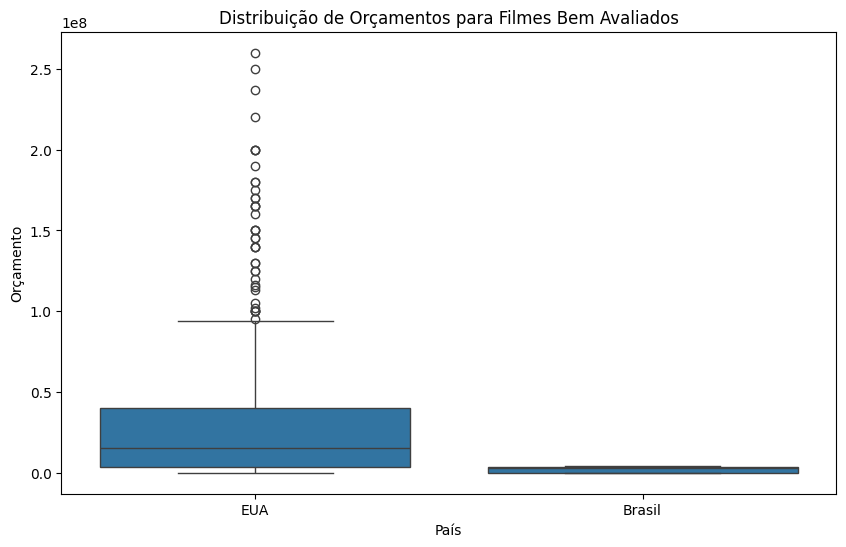

In [147]:
high_rating_films = y[y['vote_average'] >= 7.0]

budgets_us = high_rating_films[high_rating_films['production_countries'] == 'US']['budget']
budgets_br = high_rating_films[high_rating_films['production_countries'] == 'BR']['budget']

if len(budgets_us) < 2 or len(budgets_br) < 2:
    print("Dados insuficientes para realizar o teste estatístico. Cada grupo precisa de pelo menos 2 filmes com rating > 3.5.")
else:
    levene_test = stats.levene(budgets_us, budgets_br)
    t_stat, p_value = stats.ttest_ind(budgets_us, budgets_br, equal_var=False)
    # levene_test.pvalue > 0.05
    print(f"Resultados do teste t para filmes com rating > 7.0:")
    print(f"T-statistic: {t_stat:.4f}")
    print(f"P-value: {p_value:.4f}")

    # Visualiza as distribuições de orçamento em um box plot.
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='País', y='Orçamento', data=pd.DataFrame({
        'País': ['EUA'] * len(budgets_us) + ['Brasil'] * len(budgets_br),
        'Orçamento': pd.concat([budgets_us, budgets_br])
    }))
    plt.title('Distribuição de Orçamentos para Filmes Bem Avaliados')
    plt.show()

In [142]:
high_rating_films

,movieId,tmdbId,rating_mean,budget,genres,homepage,id,keywords,original_language,original_title,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,country_codes
0,1,862.0,3.921240,30000000,"[{""id"": 16, ""name"": ""Animation""}, {""id"": 35, ""...",http://toystory.disney.com/toy-story,862,"[{""id"": 931, ""name"": ""jealousy""}, {""id"": 4290,...",en,Toy Story,...,1995-10-30,373554033,81.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,NaN,Toy Story,7.7,5269,[US]
3,14,10858.0,3.432082,44000000,"[{""id"": 36, ""name"": ""History""}, {""id"": 18, ""na...",NaN,10858,"[{""id"": 840, ""name"": ""usa president""}, {""id"": ...",en,Nixon,...,1995-12-22,13681765,192.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Triumphant in Victory, Bitter in Defeat. He Ch...",Nixon,7.1,71,[US]
5,16,524.0,3.787455,52000000,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 80, ""name...",NaN,524,"[{""id"": 383, ""name"": ""poker""}, {""id"": 726, ""na...",en,Casino,...,1995-11-22,116112375,178.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,No one stays at the top forever.,Casino,7.8,1307,"[FR, US]"
6,17,4584.0,3.968573,16500000,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 10749, ""n...",NaN,4584,"[{""id"": 420, ""name"": ""bowling""}, {""id"": 818, ""...",en,Sense and Sensibility,...,1995-12-13,135000000,136.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,Lose your heart and come to your senses.,Sense and Sensibility,7.2,352,"[GB, US]"
13,25,451.0,3.689510,3600000,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 10749, ""n...",http://www.mgm.com/title_title.do?title_star=L...,451,"[{""id"": 30, ""name"": ""individual""}, {""id"": 549,...",en,Leaving Las Vegas,...,1995-10-27,49800000,112.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,I Love You... The Way You Are.,Leaving Las Vegas,7.1,360,[US]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4156,118900,228970.0,3.674312,15000000,"[{""id"": 18, ""name"": ""Drama""}]",http://howwilditwas.com/,228970,"[{""id"": 4414, ""name"": ""adventure""}, {""id"": 556...",en,Wild,...,2014-12-05,52501541,115.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,NaN,Wild,7.0,951,[US]
4162,119224,175555.0,1.500000,0,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 18, ""nam...",http://www.amadeachristmasmovie.com,175555,"[{""id"": 207317, ""name"": ""christmas""}]",en,A Madea Christmas,...,2013-12-13,0,100.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,This Little Fool Thinks She's Getting A Damn Pony,A Madea Christmas,7.0,35,[US]
4176,121155,181330.0,4.000000,0,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 99, ""nam...",http://kevinhartnation.com/portfolio/let-me-ex...,181330,"[{""id"": 9716, ""name"": ""stand-up comedy""}, {""id...",en,Kevin Hart: Let Me Explain,...,2013-07-03,32230907,74.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,Witness the rise of a legend,Kevin Hart: Let Me Explain,7.1,95,[US]
4195,127198,308639.0,3.000000,700000,"[{""id"": 80, ""name"": ""Crime""}, {""id"": 18, ""name...",http://www.youaredope.com/,308639,"[{""id"": 387, ""name"": ""california""}, {""id"": 898...",en,Dope,...,2015-06-19,17986781,103.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,It's hard out here for a geek.,Dope,7.2,691,[US]


In [153]:
br_budgets

664     2900000
1632    3300000
2667    4000000
3847          0
4131          0
Name: budget, dtype: int64

- Problema: temos muito poucos dados brasileiros. Isso pode estar influnciando os testes drasticamente.

- Teste de Shapiro-Wilk (Normalidade)

    Filmes dos EUA: O p-valor foi de 9.40×10−30 (um número extremamente baixo). Isso significa que a distribuição dos orçamentos para os filmes dos EUA não é normal. A suposição de normalidade para o teste t de Student é violada neste grupo.

    Filmes do Brasil: O p-valor foi de 0.1247. Como esse valor é maior que 0.05, não há evidências suficientes para dizer que a distribuição dos orçamentos brasileiros não é normal.

- Teste de Levene (Homogeneidade de Variâncias)

    O p-valor foi de 0.1427. Como este valor é maior que 0.05, não há evidências para rejeitar a hipótese de que as variâncias dos orçamentos dos filmes dos EUA e do Brasil são iguais.

- Teste t (Diferença de Médias)

    P-valor: O valor foi de 0.1303. Como este valor é maior que 0.05, a sua principal conclusão é que não há uma diferença estatisticamente significativa entre o orçamento médio de filmes dos EUA e do Brasil.

    T-statistic: O valor de 1.515 indica que a média dos orçamentos dos filmes dos EUA é maior que a média dos filmes do Brasil, mas essa diferença não é grande o suficiente para ser considerada estatisticamente relevante.

In [163]:
budgets_br = high_rating_films[high_rating_films['production_countries'] == 'BR']['budget']


budget_df = pd.DataFrame({
    'budgetus': [total_budget_us], 
    'budgetbr': [total_budget_br]
})


df
budget_df

,budgetus,budgetbr
0,89731471445,105200000
